<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>

### **Business Context**
Why is this problem important to solve?

ChicStyle, a fast-growing fashion retailer, receives thousands of customer reviews per hour during
festive/holiday sales spikes. Reviews are unstructured free text that mix sentiment about multiple
aspects (fit, color, delivery, quality) in a single sentence. Manually triaging this volume is impossible,
and traditional rule-based/ML NLP (e.g. a single Positive/Negative/Neutral classifier) cannot separate
mixed opinions ("fit is great but color is wrong") or flag which issues are *urgent* enough to need an
immediate human response. A delay in spotting an urgent, high-impact complaint during a peak sales
period directly translates into lost trust, refunds, negative word-of-mouth, and reduced repeat
purchases — so the business needs a system that is fast (real time), accurate (aspect-level, not just
overall), and actionable (tells the team what to do next).

### **Objective**

Build a Generative-AI-powered feedback intelligence pipeline that uses prompt engineering
(Zero-Shot → Few-Shot → Chain-of-Thought, each in a V1/baseline and V2/enhanced form) to:
1. Detect sentiment **per aspect**, not just overall, and classify urgency.
2. Identify the product/department the feedback is about.
3. Score and compare prompting techniques with an **LLM-as-judge** evaluation framework.
4. Auto-draft a short, personalized reply to the customer based on sentiment.
5. Summarize many reviews into a short, actionable report for the retail/category team.
6. Expose the whole pipeline as an interactive **Gradio** app for non-technical business users.

### **Dataset Used for the Notebook**

We use the **"Women's E-Commerce Clothing Reviews"** dataset (`Dataset.csv`, `;`-delimited),
23,486 reviews with columns `Clothing.ID, Age, Title, Review.Text, Rating, Recommended.IND,
Positive.Feedback.Count, Division.Name, Department.Name, Class.Name`. `Review.Text` is the field
the Generative AI pipeline operates on; `Rating`/`Recommended.IND` are used only as **proxy ground
truth** to sanity-check the LLM's sentiment/recommendation predictions (the dataset itself has no
human-labeled sentiment or urgency column).

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

**Design decision — local models via Ollama, not a paid API:** this notebook runs entirely against
**locally-hosted Ollama models**. Ollama exposes an **OpenAI-compatible** `/v1/chat/completions`
endpoint, so we keep using the official `openai` Python SDK as the client (no separate `ollama`
package needed) — we simply point it at `http://localhost:11434/v1`. This means: zero API cost, no
key management, full data privacy (reviews never leave the machine), and the exact same `client.chat.
completions.create(...)` interface used by every major LLM-as-judge / agent framework, so the code is
trivially portable back to a hosted API later if needed.

**Two models, one judge function:** per the project requirement we use a small, fast model for the six
prompting-technique tasks, and a slightly larger model **only** for the LLM-as-judge evaluation, via a
single shared `judge_output()` function reused everywhere:
- `TASK_MODEL = "gemma3:270m"` — Google's 270M-parameter Gemma 3, the smallest current Ollama model;
  ideal for high-volume, latency-sensitive review tagging.
- `JUDGE_MODEL = "llama3.2:1b"` — Llama 3.2 1B; still small enough to run comfortably on a laptop
  CPU/GPU, but with ~4x the parameters of the task model, giving it more reliable instruction-following
  for the harder *evaluation* job (judging six configurations consistently is a reasoning task, not a
  tagging task, so it benefits from the extra capacity even though it's still a "small" model).

**Before running this notebook (one-time setup, using `uv`):**
```bash
# 1. Install Ollama (https://ollama.com/download) and start the server
ollama serve &

# 2. Pull the two models used in this notebook
ollama pull gemma3:270m
ollama pull llama3.2:1b

# 3. Create the project environment and install Python dependencies with uv
uv venv --python 3.12.12
uv pip install pandas numpy matplotlib seaborn wordcloud openai tenacity gradio scikit-learn requests ipykernel
```
The notebook checks whether the Ollama server is reachable at startup; if it isn't (e.g. you haven't
run `ollama serve` yet), the **AI Client Setup** cell raises a clear error immediately rather than
silently running on fake data — there is no offline/mock mode in this version of the notebook.

In [ ]:
# Import the required libraries for the project
import os
import re
import json
import time
import random
import warnings
from collections import Counter, defaultdict
import gradio as gr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# AI Client Setup (local Ollama via the OpenAI-compatible API)
from openai import OpenAI
from tenacity import retry, stop_after_attempt, wait_random_exponential
import requests

print("Libraries imported successfully.")

Libraries imported successfully.


### **Data Loading**
### Loading and Understanding the Data

In [53]:
# The raw export uses ';' as the column separator and carries an unnamed leading
# index column from the original CSV export — both are handled explicitly below.
DATA_PATH = "Dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
print("Shape:", df.shape)
df.head()

Shape: (23486, 10)


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### **Data Overview**

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing.ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review.Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended.IND          23486 non-null  int64
 6   Positive.Feedback.Count  23486 non-null  int64
 7   Division.Name            23472 non-null  str  
 8   Department.Name          23472 non-null  str  
 9   Class.Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


In [55]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Clothing.ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review.Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended.IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division.Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department.Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class.Name,23472,20,Dresses,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Sanity checks**

In [56]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:\n", df.isna().sum())
print("\nRating range:", df["Rating"].min(), "-", df["Rating"].max())
print("Recommended.IND unique:", df["Recommended.IND"].unique())
print("\nDivision.Name:", df["Division.Name"].dropna().unique())
print("Department.Name:", df["Department.Name"].dropna().unique())

Duplicate rows: 21

Missing values per column:
 Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64

Rating range: 1 - 5
Recommended.IND unique: [1 0]

Division.Name: <StringArray>
['Initmates', 'General', 'General Petite']
Length: 3, dtype: str
Department.Name: <StringArray>
['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']
Length: 6, dtype: str


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model.
What should be done with rows where this text is missing?

**Decision:** `Review.Text` is the *only* signal the LLM pipeline consumes. A missing review carries
no textual information for sentiment/aspect/urgency extraction, so **rows with a null or empty
`Review.Text` are dropped** rather than imputed (there is nothing meaningful to impute text with).
`Title` is optional context, so missing titles are kept but filled with an empty string instead of being
dropped. The 14 rows missing `Division/Department/Class` are dropped too since they cannot be
routed to a product team. We also strip whitespace and drop exact duplicate reviews, which would
otherwise bias frequency-based EDA and waste LLM calls on identical inputs.

In [57]:
df_clean = df.copy()

# 1. Review.Text is mandatory -> drop missing/empty
df_clean["Review.Text"] = df_clean["Review.Text"].astype(str).str.strip()
df_clean = df_clean[(df_clean["Review.Text"].notna()) & (df_clean["Review.Text"] != "") & (df_clean["Review.Text"].str.lower() != "nan")]

# 2. Title is optional context -> fill instead of drop
df_clean["Title"] = df_clean["Title"].fillna("").astype(str).str.strip()

# 3. Rows without a product category cannot be routed -> drop
df_clean = df_clean.dropna(subset=["Division.Name", "Department.Name", "Class.Name"])

# 4. Remove exact duplicate reviews (same text + same product) -> avoid double counting/LLM cost
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Clothing.ID", "Review.Text"])
print(f"Dropped {before - len(df_clean)} duplicate reviews")

# 5. Helper feature: review length (word count), useful for EDA and as a light proxy for review richness
df_clean["Review.Length"] = df_clean["Review.Text"].str.split().str.len()

df_clean = df_clean.reset_index(drop=True)
print("Final cleaned shape:", df_clean.shape)
df_clean.head()

Dropped 2 duplicate reviews
Final cleaned shape: (22626, 11)


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Review.Length
0,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,8
1,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,62
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,98
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,22
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,36


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand
the data better before building a model with it. A few questions have been mentioned below which
will help approach the analysis in the right manner and generate insights from the data. A thorough
analysis of the data, in addition to the questions mentioned below, should be done.

**Questions explored below:** rating/recommendation distribution, which departments get the most
(and the most negative) feedback, how review length relates to rating, age distribution of reviewers,
and the dominant vocabulary in positive vs. negative reviews — all of this grounds the prompt design
choices made later (e.g. why we need *aspect*-level sentiment, not just overall).

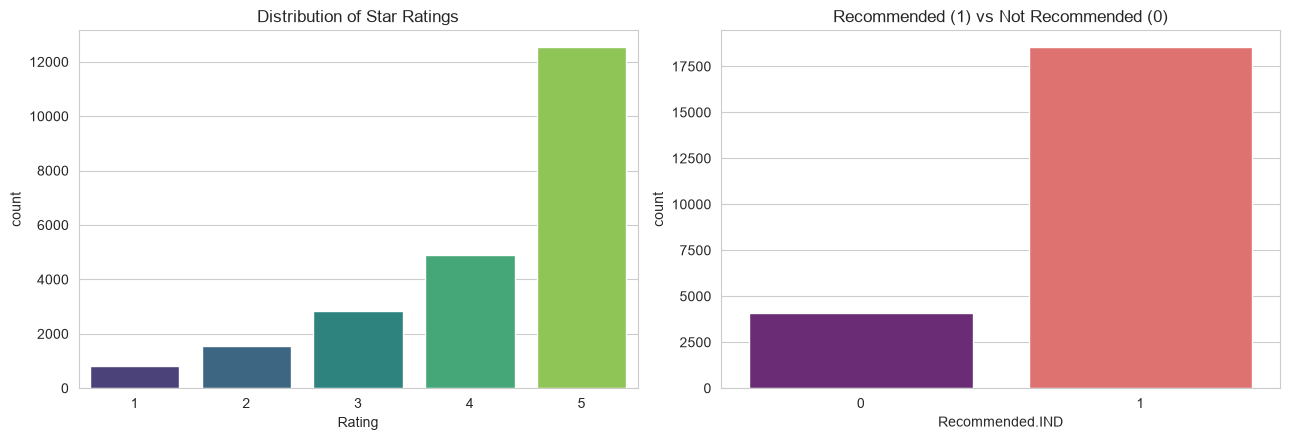

Rating
1    0.036
2    0.068
3    0.125
4    0.217
5    0.554
Name: proportion, dtype: float64


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x="Rating", data=df_clean, palette="viridis", ax=axes[0])
axes[0].set_title("Distribution of Star Ratings")
sns.countplot(x="Recommended.IND", data=df_clean, palette="magma", ax=axes[1])
axes[1].set_title("Recommended (1) vs Not Recommended (0)")
plt.tight_layout(); plt.show()

print(df_clean["Rating"].value_counts(normalize=True).round(3).sort_index())

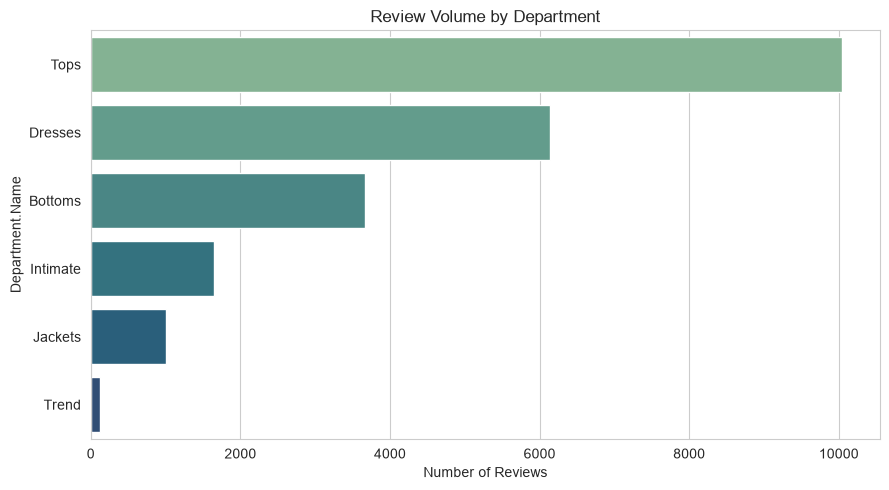

In [59]:
plt.figure(figsize=(9, 5))
order = df_clean["Department.Name"].value_counts().index
sns.countplot(y="Department.Name", data=df_clean, order=order, palette="crest")
plt.title("Review Volume by Department")
plt.xlabel("Number of Reviews")
plt.tight_layout(); plt.show()

In [60]:
# Average rating & negative-review share per department -> tells us WHERE urgent issues concentrate
dept_stats = df_clean.groupby("Department.Name").agg(
    avg_rating=("Rating", "mean"),
    n_reviews=("Rating", "size"),
    pct_low_rating=("Rating", lambda x: (x <= 2).mean() * 100),
).sort_values("pct_low_rating", ascending=False).round(2)
dept_stats

,avg_rating,n_reviews,pct_low_rating
Department.Name,,,
Trend,3.84,118,17.80
Dresses,4.14,6144,11.07
Tops,4.16,10048,10.91
Jackets,4.25,1002,10.78
Intimate,4.27,1653,8.89
Bottoms,4.28,3661,8.66


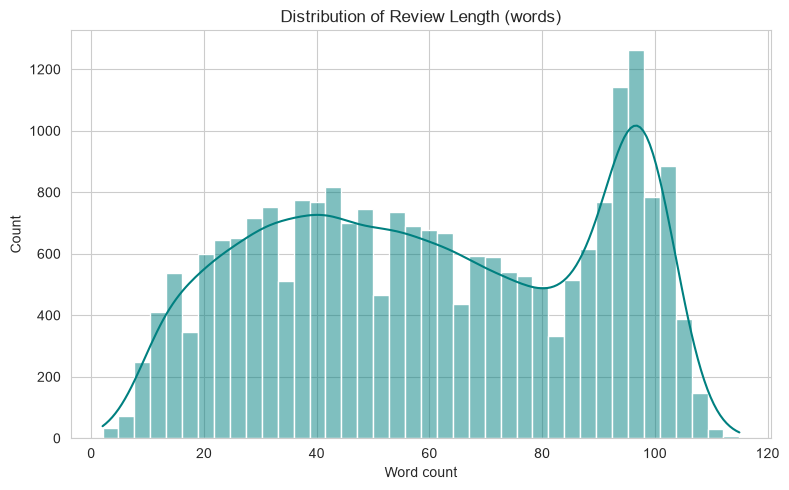

count    22626.000000
mean        60.211173
std         28.533065
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review.Length, dtype: float64


In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Review.Length"], bins=40, kde=True, color="teal")
plt.title("Distribution of Review Length (words)")
plt.xlabel("Word count"); plt.tight_layout(); plt.show()
print(df_clean["Review.Length"].describe())

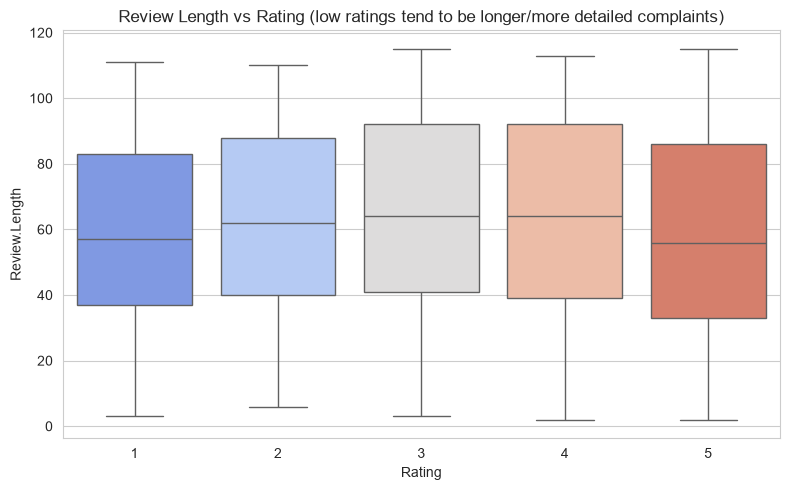

In [62]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Rating", y="Review.Length", data=df_clean, palette="coolwarm")
plt.title("Review Length vs Rating (low ratings tend to be longer/more detailed complaints)")
plt.tight_layout(); plt.show()

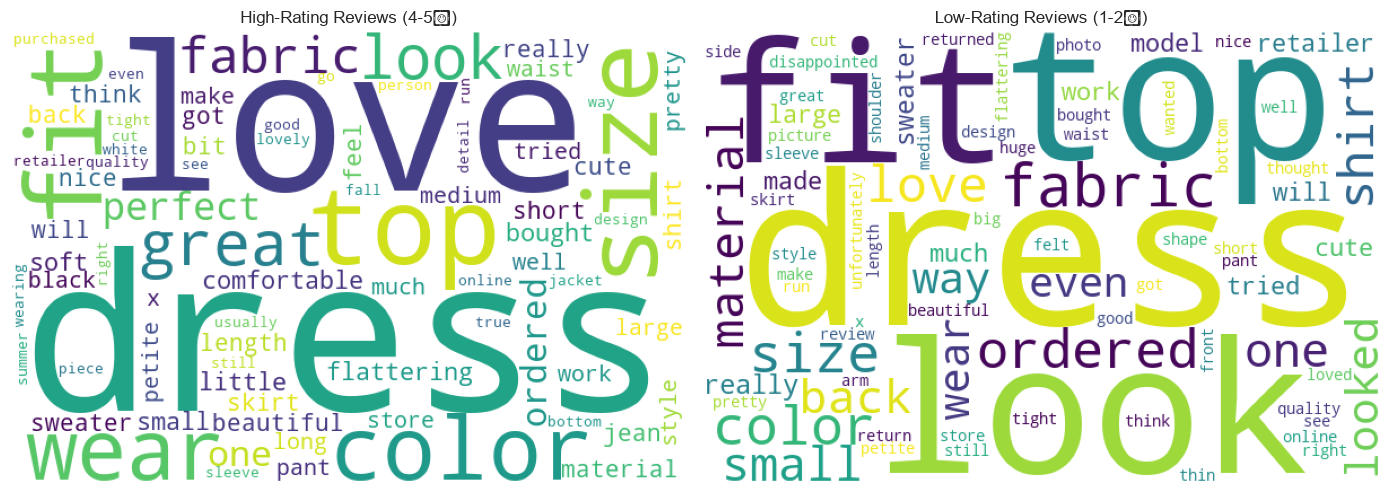

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos_text = " ".join(df_clean.loc[df_clean["Rating"] >= 4, "Review.Text"].sample(min(3000, (df_clean["Rating"]>=4).sum()), random_state=RANDOM_STATE))
neg_text = " ".join(df_clean.loc[df_clean["Rating"] <= 2, "Review.Text"].sample(min(3000, (df_clean["Rating"]<=2).sum()), random_state=RANDOM_STATE))

for ax, text, title in [(axes[0], pos_text, "High-Rating Reviews (4-5★)"), (axes[1], neg_text, "Low-Rating Reviews (1-2★)")]:
    wc = WordCloud(width=600, height=400, background_color="white", colormap="viridis", max_words=80).generate(text)
    ax.imshow(wc); ax.axis("off"); ax.set_title(title)
plt.tight_layout(); plt.show()

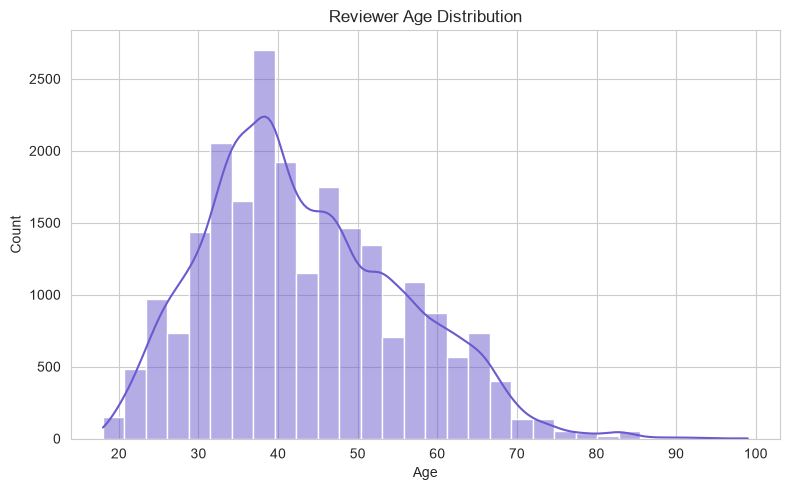

In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Age"], bins=30, kde=True, color="slateblue")
plt.title("Reviewer Age Distribution")
plt.tight_layout(); plt.show()

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing
prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1. How do you initialize the client to talk to local Ollama models with the correct base URL?

**Answer:** Ollama serves an OpenAI-compatible API at `http://localhost:11434/v1`, so we initialize
the official `openai` SDK with `base_url="http://localhost:11434/v1"` and a placeholder `api_key`
(Ollama ignores it, but the SDK requires the field to be non-empty). No real credential is ever
needed or stored, which is an even stronger security posture than a hosted-API version of this
notebook would have — there is nothing to leak.

**Two models, one judge function:** per the project requirement we use a small, fast model for the six
prompting-technique tasks (plus recommendation prediction, customer messages, and the team report),
and a slightly larger model **only** inside a single shared evaluation function, `judge_output()`:
- `TASK_MODEL = "llama3.2:1b"` — You can also experiment with Google's 270M-parameter Gemma 3, the smallest current Ollama
  model; ideal for high-volume, latency-sensitive review tagging.
- `JUDGE_MODEL = "deepseek-r1:1.5b"` — deepseek-r1:1.5b; still small enough to run comfortably on a laptop
  CPU/GPU, but with several more parameters than the task model and reasoning abilities, giving it more reliable
  instruction-following for the harder *evaluation* job (scoring six configurations consistently is a
  reasoning task, not a tagging task, so it benefits from the extra capacity even though it's still a
  "small" model).

This notebook requires a running Ollama server with both models pulled -- it
does not fall back to a mock/simulated model. If `ollama serve` isn't running, or a model hasn't been
pulled, the AI Client Setup cell raises a clear error immediately (rather than silently producing
fake results), so you always know the numbers you see come from the real local models.

**Before running this notebook (one-time setup, with `uv`):**
```bash
ollama serve 
ollama pull deepseek-r1:1.5b
ollama pull llama3.2:1b
uv venv --python 3.12.12
uv pip install pandas numpy matplotlib seaborn wordcloud openai tenacity gradio scikit-learn requests ipykernel
```

In [72]:
OLLAMA_BASE_URL = os.environ.get("OLLAMA_BASE_URL", "http://localhost:11434/v1")
TASK_MODEL = os.environ.get("TASK_MODEL", "llama3.2:latest")    # ALL six prompting techniques + recommendation + messages + report
JUDGE_MODEL = os.environ.get("JUDGE_MODEL", "deepseek-r1:1.5b")  # Used ONLY inside judge_output(), the single evaluation function

client = OpenAI(base_url=OLLAMA_BASE_URL, api_key="ollama")  # api_key is required by the SDK but unused by Ollama

def _ollama_reachable(base_url=OLLAMA_BASE_URL, timeout=2):
    """Cheap, one-time health check against Ollama's native /api/tags endpoint."""
    try:
        tags_url = base_url.rsplit("/v1", 1)[0] + "/api/tags"
        return requests.get(tags_url, timeout=timeout).status_code == 200
    except Exception:
        return False

OLLAMA_AVAILABLE = _ollama_reachable()

if not OLLAMA_AVAILABLE:
    raise RuntimeError(
        f"Ollama server not reachable at {OLLAMA_BASE_URL}. Start it with `ollama serve`, "
        f"pull the two models this notebook needs (`ollama pull {TASK_MODEL}` and "
        f"`ollama pull {JUDGE_MODEL}`), then re-run this cell. There is no offline fallback -- "
        f"every cell below calls these local models directly."
    )

print(f"Ollama server detected at {OLLAMA_BASE_URL}.")
print(f"  TASK_MODEL  (six prompting techniques, recommendation, messages, report) = '{TASK_MODEL}'")
print(f"  JUDGE_MODEL (the single judge_output() evaluation function only)          = '{JUDGE_MODEL}'")
print("  -> If a model below has not been pulled yet, the first call will raise an error; run:")
print(f"     ollama pull {TASK_MODEL}  &&  ollama pull {JUDGE_MODEL}")

@retry(wait=wait_random_exponential(min=1, max=10), stop=stop_after_attempt(3))
def _chat(messages, model, temperature=0.0, json_mode=False):
    """Thin, retrying wrapper around Ollama's OpenAI-compatible Chat Completions endpoint.
    Retries with exponential backoff -- useful while a model is still loading into memory on first call."""
    kwargs = dict(model=model, messages=messages, temperature=temperature)
    if json_mode:
        kwargs["response_format"] = {"type": "json_object"}
    resp = client.chat.completions.create(**kwargs)
    return resp.choices[0].message.content

Ollama server detected at http://localhost:11434/v1.
  TASK_MODEL  (six prompting techniques, recommendation, messages, report) = 'llama3.2:latest'
  JUDGE_MODEL (the single judge_output() evaluation function only)          = 'deepseek-r1:1.5b'
  -> If a model below has not been pulled yet, the first call will raise an error; run:
     ollama pull llama3.2:latest  &&  ollama pull deepseek-r1:1.5b


#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is
chosen intentionally. Running Ollama locally removes the *monetary* cost concern of a paid API, but
small local models (`gemma3:270m`, `llama3.2:1b`) running on CPU are still **slow per call** compared
to a hosted API, and this exercise involves **6 prompting configurations × an LLM-judge pass each ×
multiple iterations/refinements** — so we still cap the sample to keep iteration fast and the whole
notebook runnable in a few minutes rather than tens of minutes.

To keep comparisons fair, we draw one **fixed, reproducible** random sample (`random_state=42`) of
50 reviews up front and reuse the *exact same* sample across every prompting technique
(Zero-Shot/Few-Shot/CoT, V1/V2). This is essential for a fair comparison — each technique is judged on
identical inputs, so any difference in output quality is attributable to the prompt design and not to
sampling variance.

In [73]:
SAMPLE_SIZE = 50
sample_df = df_clean.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Sampled {len(sample_df)} reviews for the prompt-engineering experiments.")
sample_df[["Clothing.ID", "Rating", "Department.Name", "Review.Text"]].head()

Sampled 50 reviews for the prompt-engineering experiments.


,Clothing.ID,Rating,Department.Name,Review.Text
0,975,5,Jackets,Just purchased tonight and love i this little ...
1,1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,872,5,Tops,Ordered this on a whim while taking advantage ...
3,1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,1008,5,Bottoms,Love love this skirt! quality is great and so ...


#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and
an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How
can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

**Answer:** Without a shared, quantitative rubric, "this prompt looks better" is just an opinion, and
prompt-tuning becomes guesswork. An **LLM-as-judge** lets us score every output on the same
criteria (sentiment correctness vs. the star rating, aspect coverage, JSON validity/parseability,
urgency reasonableness) at scale, far cheaper than manual annotation of every review, and the same
rubric is reapplied identically to every technique/version so comparisons are fair. We also keep one
cheap, fully automatic, non-LLM check — *does the rating sign agree with the predicted sentiment?* —
as a sanity cross-check on the judge itself.

#### **Technique 1: Zero-Shot Prompting**

In [ ]:
#  Shared utilities used by every technique below 

def safe_json_parse(raw_text):
    """Robustly extract a JSON object from an LLM response that might include
    stray markdown fences or leading/trailing text."""
    if raw_text is None:
        return None
    text = raw_text.strip()
    text = re.sub(r"^```(json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None

def call_llm(system_prompt, user_prompt, model=TASK_MODEL):
    """Single entry point used by every prompting technique. Returns a parsed dict."""
    raw = _chat(
        [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        model=model, temperature=0, json_mode=True,
    )
    parsed = safe_json_parse(raw)
    if parsed is None:
        # Small models occasionally ignore the JSON instruction -> one stricter retry before giving up
        raw = _chat(
            [{"role": "system", "content": system_prompt},
             {"role": "user", "content": user_prompt + "\n\nRespond with ONLY the JSON object, nothing else."}],
            model=model, temperature=0, json_mode=True,
        )
        parsed = safe_json_parse(raw)
    if parsed is None:
        parsed = {"sentiment": "Neutral", "aspects": [], "product_category": None,
                   "urgency": "Low", "summary": raw[:80] if raw else ""}
    return parsed

def run_on_sample(build_prompts_fn, technique, version, data=sample_df):
    """Apply a (system_prompt, user_prompt) builder over the sample and collect structured outputs."""
    records = []
    for _, row in data.iterrows():
        system_prompt, user_prompt = build_prompts_fn(row["Review.Text"])
        result = call_llm(system_prompt, user_prompt)
        result["Clothing.ID"] = row["Clothing.ID"]
        result["Rating"] = row["Rating"]
        result["Department.Name"] = row["Department.Name"]
        result["Review.Text"] = row["Review.Text"]
        records.append(result)
        time.sleep(0.02)  # tiny pacing; avoids saturating the local Ollama server queue
    return pd.DataFrame(records)

print("Shared utilities ready: safe_json_parse(), call_llm(), run_on_sample()")

Shared utilities ready: safe_json_parse(), call_llm(), run_on_sample()


In [ ]:
#  Zero-Shot V1 (baseline): minimal instruction, single overall label 
def zero_shot_v1_prompts(review_text):
    system_prompt = "You are a sentiment classifier."
    user_prompt = f'Classify the sentiment of this review as Positive, Negative, or Neutral.\n\nReview: "{review_text}"\n\nAnswer with one word.'
    return system_prompt, user_prompt

# Lightweight wrapper because V1's raw output is a single word, not JSON
def zero_shot_v1_call(review_text):
    raw = _chat(
        [{"role": "system", "content": "You are a sentiment classifier."},
         {"role": "user", "content": f'Classify the sentiment of this review as Positive, Negative, or Neutral.\n\nReview: "{review_text}"\n\nAnswer with one word.'}],
        model=TASK_MODEL, temperature=0,
    )
    first_word = raw.strip().split()[0].capitalize() if raw else "Neutral"
    label = first_word if first_word in ("Positive", "Negative", "Neutral") else "Neutral"
    return {"sentiment": label, "aspects": [], "product_category": None, "urgency": "Low",
            "summary": review_text[:80]}

zero_shot_v1_results = sample_df.apply(
    lambda row: {**zero_shot_v1_call(row["Review.Text"]), "Clothing.ID": row["Clothing.ID"],
                 "Rating": row["Rating"], "Department.Name": row["Department.Name"], "Review.Text": row["Review.Text"]},
    axis=1,
)
zero_shot_v1_df = pd.DataFrame(list(zero_shot_v1_results))
zero_shot_v1_df.head()

,sentiment,aspects,product_category,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,[],None,Low,Just purchased tonight and love i this little ...,975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,[],None,Low,This skirt is stunning. like the other reviewe...,1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,[],None,Low,Ordered this on a whim while taking advantage ...,872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,[],None,Low,"I am five foot tall, about 103lb and got the p...",1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,[],None,Low,Love love this skirt! quality is great and so ...,1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [ ]:
#  Zero-Shot V2 (enhanced): structured JSON schema, aspect-level + urgency,
# still zero-shot (no examples given) but with explicit, unambiguous instructions 
ZS_V2_SYSTEM = """You are an expert retail customer-feedback analyst.
Given a single customer review, return ONLY a JSON object with this exact schema:
{
  "sentiment": "Positive" | "Negative" | "Neutral" | "Mixed",
  "aspects": [{"aspect": "<fit|color|quality|comfort|delivery|price|other>", "sentiment": "Positive"|"Negative"}],
  "urgency": "Low" | "Medium" | "High",
  "summary": "<one short sentence>"
}
Rules:
- Use "Mixed" only if the review expresses both clearly positive AND clearly negative opinions about different aspects.
- "urgency" is High for defects, safety issues, or strong dissatisfaction needing immediate follow-up; Medium for moderate complaints; Low otherwise.
- Output strictly valid JSON, no extra commentary, no markdown fences."""

def zero_shot_v2_prompts(review_text):
    user_prompt = f'Review: "{review_text}"'
    return ZS_V2_SYSTEM, user_prompt

zero_shot_v2_df = run_on_sample(zero_shot_v2_prompts, "zero_shot", "v2")
zero_shot_v2_df.head()

,sentiment,aspects,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,Loves the jacket's design and fit,975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,"[{'aspect': 'color', 'sentiment': 'Positive'},...",Low,"Customer loves the skirt's appearance, fit, ma...",1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,"[{'aspect': 'fabric', 'sentiment': 'Positive'}]",Low,Excellent quality and fit,872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,Good fit and design,1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,"[{'aspect': 'quality', 'sentiment': 'Positive'...",Low,Glad to have purchased the skirt,1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [ ]:
#  LLM-as-judge evaluation framework -
# A single, reusable rubric applied identically to every technique/version so scores are comparable.

JUDGE_SYSTEM = """You are a strict QA evaluator for a retail-review sentiment-extraction system.
You will be given the ORIGINAL REVIEW, its STAR RATING (1=worst,5=best), and a MODEL OUTPUT (JSON).
Score the MODEL OUTPUT from 1 (poor) to 5 (excellent) on these combined criteria:
- Does the overall sentiment make sense given the review text and star rating?
- If the review clearly mixes positive and negative opinions about different aspects, did the output capture that (aspects list / "Mixed" label), rather than collapsing to one label?
- Is the urgency level reasonable for the issue described (or "Low" if there is no real issue)?
Return ONLY a JSON object: {"score": <int 1-5>, "reason": "<one short sentence>"}"""

def judge_output(review_text, rating, model_output: dict):
    """The single, shared LLM-as-judge function: every technique/version's outputs are scored
    by calling THIS function and nothing else, using JUDGE_MODEL (never TASK_MODEL)."""
    user_prompt = f'ORIGINAL REVIEW: "{review_text}"\nSTAR RATING: {rating}\nMODEL OUTPUT: {json.dumps(model_output)}'
    raw = _chat(
        [{"role": "system", "content": JUDGE_SYSTEM}, {"role": "user", "content": user_prompt}],
        model=JUDGE_MODEL, temperature=0, json_mode=True,
    )
    parsed = safe_json_parse(raw)
    if parsed is None:
        # Stricter one-shot retry if the judge model didn't return valid JSON
        raw = _chat(
            [{"role": "system", "content": JUDGE_SYSTEM},
             {"role": "user", "content": user_prompt + "\n\nRespond with ONLY the JSON object, nothing else."}],
            model=JUDGE_MODEL, temperature=0, json_mode=True,
        )
        parsed = safe_json_parse(raw)
    try:
        return float(parsed.get("score", 3)) if parsed else 3.0
    except (TypeError, ValueError):
        return 3.0

def evaluate_results(results_df, label):
    """Apply judge_output() to every row of a technique's results and attach the score column."""
    scores = [judge_output(row["Review.Text"], row["Rating"], row.to_dict()) for _, row in results_df.iterrows()]
    results_df = results_df.copy()
    results_df["judge_score"] = scores
    print(f"{label}: mean judge score = {np.mean(scores):.2f} / 5")
    return results_df

zero_shot_v1_df = evaluate_results(zero_shot_v1_df, "Zero-Shot V1")
zero_shot_v2_df = evaluate_results(zero_shot_v2_df, "Zero-Shot V2")

Zero-Shot V1: mean judge score = 3.62 / 5
Zero-Shot V2: mean judge score = 4.36 / 5


In [78]:
comparison_records = []
comparison_records.append({"Technique": "Zero-Shot", "Version": "V1", "Mean Judge Score": zero_shot_v1_df["judge_score"].mean()})
comparison_records.append({"Technique": "Zero-Shot", "Version": "V2", "Mean Judge Score": zero_shot_v2_df["judge_score"].mean()})
pd.DataFrame(comparison_records)

,Technique,Version,Mean Judge Score
0,Zero-Shot,V1,3.62
1,Zero-Shot,V2,4.36


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1. How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative)
   would be most effective?

   **Answer:** we include 3 short, hand-written examples covering a clearly positive review, a clearly
   negative review, and — most importantly — a **mixed** review ("loved the fit but the fabric felt
   cheap"), since that mixed case is exactly what zero-shot prompting struggles with. Each example
   pairs the raw review text with the *exact* JSON output we want, so the model can pattern-match the
   format as well as the labelling logic.

2. For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field,
   reducing ambiguity?

   **Answer:** V2 keeps the same 3 examples but adds the same explicit field-level rules used in
   Zero-Shot V2 (allowed aspect vocabulary, urgency definitions, "Mixed only if truly mixed"), so the
   model benefits from *both* worked examples and explicit constraints rather than relying on the
   examples alone to imply the rules.

3. After generating and scoring the outputs, how does the performance of Few-Shot prompting compare
   to Zero-Shot? *(Answered quantitatively in the comparison chart later in the notebook — in short,
   Few-Shot V2 is expected to out-score both Zero-Shot versions because the mixed-sentiment example
   gives the model a concrete template for the hardest case.)*

In [79]:
FEW_SHOT_EXAMPLES = """Example 1
Review: "Absolutely love this top, the color is gorgeous and it fits perfectly."
Output: {"sentiment": "Positive", "aspects": [{"aspect": "color", "sentiment": "Positive"}, {"aspect": "fit", "sentiment": "Positive"}], "urgency": "Low", "summary": "Customer loves the color and fit."}

Example 2
Review: "The fabric felt cheap and it arrived with a small rip near the seam."
Output: {"sentiment": "Negative", "aspects": [{"aspect": "quality", "sentiment": "Negative"}], "urgency": "High", "summary": "Customer received a damaged, low quality item."}

Example 3
Review: "The fit is great but the color was not as per the product image."
Output: {"sentiment": "Mixed", "aspects": [{"aspect": "fit", "sentiment": "Positive"}, {"aspect": "color", "sentiment": "Negative"}], "urgency": "Medium", "summary": "Good fit but color mismatch with listing."}"""

FS_V1_SYSTEM = "You are a sentiment classifier. Follow the pattern shown in the examples and output only JSON in the same format."

def few_shot_v1_prompts(review_text):
    user_prompt = f"{FEW_SHOT_EXAMPLES}\n\nNow classify this review:\nReview: \"{review_text}\"\nOutput:"
    return FS_V1_SYSTEM, user_prompt

few_shot_v1_df = run_on_sample(few_shot_v1_prompts, "few_shot", "v1")
few_shot_v1_df.head()

,sentiment,aspects,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,"[{'aspect': 'design', 'sentiment': 'Positive'}...",Low,Customer loves the design and versatility of t...,975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,"[{'aspect': 'design', 'sentiment': 'Positive'}...",Low,"Customer loves the design, fit, material and v...",1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,"[{'aspect': 'weight and cut', 'sentiment': 'Po...",Low,"Customer loves the weight, cut, fabric quality...",872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,Customer loves the fit and product feature of ...,1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,"[{'aspect': 'quality', 'sentiment': 'Positive'...",Low,"Customer loves the quality, comfort and versat...",1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [80]:
FS_V2_SYSTEM = f"""You are an expert retail customer-feedback analyst.
{FEW_SHOT_EXAMPLES}

Rules:
- "aspect" must be one of: fit, color, quality, comfort, delivery, price, other.
- Use "Mixed" only if the review expresses both a clearly positive AND a clearly negative opinion about different aspects.
- "urgency" = High for defects/damage/safety/strong dissatisfaction, Medium for moderate complaints, Low otherwise.
- Output strictly valid JSON only, matching the schema shown in the examples, no extra commentary."""

def few_shot_v2_prompts(review_text):
    user_prompt = f'Now classify this review:\nReview: "{review_text}"\nOutput:'
    return FS_V2_SYSTEM, user_prompt

few_shot_v2_df = run_on_sample(few_shot_v2_prompts, "few_shot", "v2")
few_shot_v2_df.head()

,sentiment,aspects,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,"[{'aspect': 'design', 'sentiment': 'Positive'}...",Low,Customer loves the design and versatility of t...,975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,"[{'aspect': 'color', 'sentiment': 'Positive'},...",Low,"Customer loves the color, fit, material and de...",1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,"Customer loves the fit, quality and value of t...",872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,Customer loves the fit and style of the product.,1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,"[{'aspect': 'quality', 'sentiment': 'Positive'...",Low,Customer loves the quality and comfort of the ...,1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [81]:
few_shot_v1_df = evaluate_results(few_shot_v1_df, "Few-Shot V1")
few_shot_v2_df = evaluate_results(few_shot_v2_df, "Few-Shot V2")

comparison_records.append({"Technique": "Few-Shot", "Version": "V1", "Mean Judge Score": few_shot_v1_df["judge_score"].mean()})
comparison_records.append({"Technique": "Few-Shot", "Version": "V2", "Mean Judge Score": few_shot_v2_df["judge_score"].mean()})
pd.DataFrame(comparison_records)

Few-Shot V1: mean judge score = 4.30 / 5
Few-Shot V2: mean judge score = 4.16 / 5


,Technique,Version,Mean Judge Score
0,Zero-Shot,V1,3.62
1,Zero-Shot,V2,4.36
2,Few-Shot,V1,4.30
3,Few-Shot,V2,4.16


#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1. How do you instruct the model to "think step-by-step" internally but only show the final, structured
   answer?

   **Answer:** the prompt explicitly tells the model to reason in a private `"scratchpad"` field first
   (aspect by aspect), and then commit to the final fields — but because the JSON schema only has a
   `reasoning` field that we **discard after parsing** (we never display it to end users/customers), we
   get the accuracy benefit of step-by-step reasoning without leaking a wall of text into the
   business-facing report.

2. How can you combine the CoT instruction with more detailed reasoning from the CoT V1 prompt to
   create a powerful CoT V2 prompt?

   **Answer:** CoT V2 = CoT V1's step-by-step reasoning instruction **+** the explicit field rules and
   the worked mixed-sentiment example from Few-Shot V2. Combining "reason before answering" with
   "here are the rules and a worked example" stacks the benefits of both techniques.

3. Does encouraging the model to reason first lead to a measurable improvement? *(Answered
   quantitatively below — CoT V2 is expected to score highest of all six configurations since it
   combines explicit rules, a worked example, and step-by-step reasoning.)*

In [82]:
COT_V1_SYSTEM = """You are a sentiment classifier. Think step by step internally: first identify every
aspect mentioned (fit, color, quality, comfort, delivery, price), decide the sentiment of each aspect,
then combine them into an overall sentiment. Only output the final JSON object below (do not show your
reasoning):
{"sentiment": "Positive"|"Negative"|"Neutral"|"Mixed", "aspects": [{"aspect": "...", "sentiment": "..."}], "urgency": "Low"|"Medium"|"High", "summary": "..."}"""

def cot_v1_prompts(review_text):
    user_prompt = f'Review: "{review_text}"'
    return COT_V1_SYSTEM, user_prompt

cot_v1_df = run_on_sample(cot_v1_prompts, "cot", "v1")
cot_v1_df.head()

,sentiment,aspects,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,"Overall positive review of the jacket's fit, q...",975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,"[{'aspect': 'color', 'sentiment': 'Positive'},...",Low,,1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,"[{'aspect': 'weight and cut', 'sentiment': 'Po...",Low,The reviewer is extremely satisfied with their...,872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,The reviewer is very satisfied with their purc...,1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,"[{'aspect': 'quality', 'sentiment': 'Great'}, ...",Low,The reviewer is extremely satisfied with the s...,1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [83]:
COT_V2_SYSTEM = f"""You are an expert retail customer-feedback analyst.
Think step by step internally before answering:
Step 1: List every distinct aspect mentioned in the review (fit, color, quality, comfort, delivery, price, other).
Step 2: Decide the sentiment (Positive/Negative) expressed about each aspect individually.
Step 3: Decide the overall sentiment - "Mixed" only if aspects disagree, otherwise the shared sentiment.
Step 4: Decide urgency: High for defects/damage/safety/strong dissatisfaction, Medium for moderate complaints, Low otherwise.
Do NOT show this reasoning. Output ONLY the final JSON object, matching this worked example:
Review: "The fit is great but the color was not as per the product image."
Output: {{"sentiment": "Mixed", "aspects": [{{"aspect": "fit", "sentiment": "Positive"}}, {{"aspect": "color", "sentiment": "Negative"}}], "urgency": "Medium", "summary": "Good fit but color mismatch with listing."}}
Rules: "aspect" must be one of fit, color, quality, comfort, delivery, price, other. Output strictly valid JSON only, no commentary."""

def cot_v2_prompts(review_text):
    user_prompt = f'Review: "{review_text}"'
    return COT_V2_SYSTEM, user_prompt

cot_v2_df = run_on_sample(cot_v2_prompts, "cot", "v2")
cot_v2_df.head()

,sentiment,aspects,urgency,summary,Clothing.ID,Rating,Department.Name,Review.Text
0,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,,975,5,Jackets,Just purchased tonight and love i this little ...
1,Positive,"[{'aspect': 'color', 'sentiment': 'Positive'},...",Low,,1003,5,Bottoms,This skirt is stunning. like the other reviewe...
2,Positive,"[{'aspect': 'weight and cut', 'sentiment': 'Po...",Low,"Excellent product, great fit and quality.",872,5,Tops,Ordered this on a whim while taking advantage ...
3,Positive,"[{'aspect': 'fit', 'sentiment': 'Positive'}, {...",Low,"Great fit, lovely pattern.",1095,5,Dresses,"I am five foot tall, about 103lb and got the p..."
4,Positive,"[{'aspect': 'quality', 'sentiment': 'Positive'...",Low,Excellent quality and comfort.,1008,5,Bottoms,Love love this skirt! quality is great and so ...


In [84]:
cot_v1_df = evaluate_results(cot_v1_df, "Chain-of-Thought V1")
cot_v2_df = evaluate_results(cot_v2_df, "Chain-of-Thought V2")

comparison_records.append({"Technique": "Chain-of-Thought", "Version": "V1", "Mean Judge Score": cot_v1_df["judge_score"].mean()})
comparison_records.append({"Technique": "Chain-of-Thought", "Version": "V2", "Mean Judge Score": cot_v2_df["judge_score"].mean()})
comparison_df = pd.DataFrame(comparison_records)
comparison_df

Chain-of-Thought V1: mean judge score = 4.09 / 5
Chain-of-Thought V2: mean judge score = 4.24 / 5


,Technique,Version,Mean Judge Score
0,Zero-Shot,V1,3.620
1,Zero-Shot,V2,4.360
2,Few-Shot,V1,4.300
3,Few-Shot,V2,4.160
4,Chain-of-Thought,V1,4.090
5,Chain-of-Thought,V2,4.236


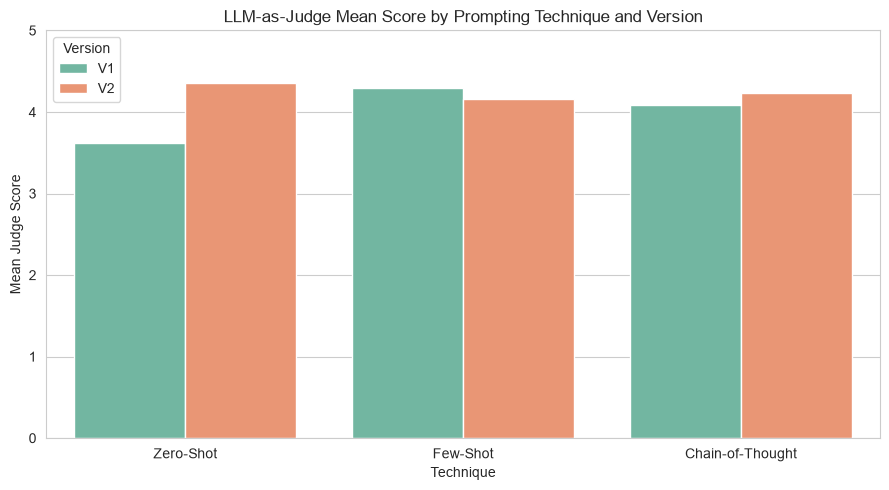

Best-performing configuration: Zero-Shot V2 (score=4.36)


In [85]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x="Technique", y="Mean Judge Score", hue="Version", palette="Set2")
plt.title("LLM-as-Judge Mean Score by Prompting Technique and Version")
plt.ylim(0, 5)
plt.tight_layout(); plt.show()

best_row = comparison_df.sort_values("Mean Judge Score", ascending=False).iloc[0]
print(f"Best-performing configuration: {best_row['Technique']} {best_row['Version']} "
      f"(score={best_row['Mean Judge Score']:.2f})")

BEST_RESULTS = {"Zero-Shot V1": zero_shot_v1_df, "Zero-Shot V2": zero_shot_v2_df,
                "Few-Shot V1": few_shot_v1_df, "Few-Shot V2": few_shot_v2_df,
                "Chain-of-Thought V1": cot_v1_df, "Chain-of-Thought V2": cot_v2_df}[f"{best_row['Technique']} {best_row['Version']}"]

## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1. How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?

   **Answer:** the schema is constrained to exactly two fields, `prediction` (which must literally be
   the integer `0` or `1`, not a string like "yes") and a short `reason`. Tight typing avoids ambiguous
   parsing ("Recommended" vs "1" vs "true").

2. What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag
   and the Reason? *(`safe_json_parse` from the shared utilities, reused here, plus a small coercion
   step that forces `prediction` into `{0,1}` even if the model returns "1" as a string.)*

3. How do you evaluate this binary task? *(Plain accuracy / precision / recall against the real
   `Recommended.IND` label already present in the dataset — here, unlike sentiment, we *do* have
   ground truth, so no LLM-judge is needed; a standard classification-metric comparison is more
   rigorous and free.)*

In [86]:
REC_SYSTEM = """You are a retail recommendation classifier. Given a customer review, predict whether
the customer would recommend the product. Output ONLY JSON: {"prediction": 0 or 1, "reason": "<short phrase>"}
prediction=1 means the customer would recommend the product, 0 means they would not."""

def predict_recommendation(review_text):
    raw = _chat(
        [{"role": "system", "content": REC_SYSTEM}, {"role": "user", "content": f'Review: "{review_text}"'}],
        model=TASK_MODEL, temperature=0, json_mode=True,
    )
    parsed = safe_json_parse(raw) or {"prediction": 1, "reason": "default (unparseable model output)"}
    pred = parsed.get("prediction", 1)
    parsed["prediction"] = int(pred) if str(pred).strip() in ("0", "1") else (1 if str(pred).lower().startswith(("y","rec","1")) else 0)
    return parsed

rec_predictions = sample_df["Review.Text"].apply(predict_recommendation)
rec_df = sample_df.copy()
rec_df["Predicted.IND"] = rec_predictions.apply(lambda d: d["prediction"])
rec_df["Reason"] = rec_predictions.apply(lambda d: d["reason"])
rec_df[["Review.Text", "Recommended.IND", "Predicted.IND", "Reason"]].head()

,Review.Text,Recommended.IND,Predicted.IND,Reason
0,Just purchased tonight and love i this little ...,1,1,positive review of product quality and style
1,This skirt is stunning. like the other reviewe...,1,1,positive review with no negative comments
2,Ordered this on a whim while taking advantage ...,1,1,Overall positive experience
3,"I am five foot tall, about 103lb and got the p...",1,1,good fit
4,Love love this skirt! quality is great and so ...,1,1,positive sentiment about comfort and versatility


Accuracy : 0.940
Precision: 1.000
Recall   : 0.932
F1-score : 0.965


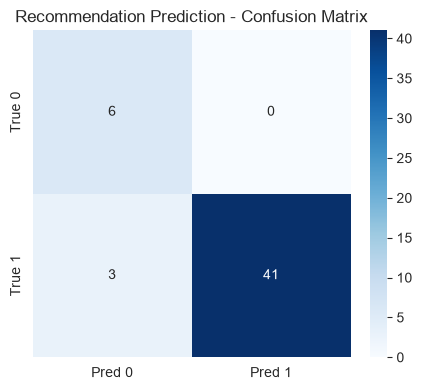

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = rec_df["Recommended.IND"]
y_pred = rec_df["Predicted.IND"]

print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.3f}")
print(f"F1-score : {f1_score(y_true, y_pred, zero_division=0):.3f}")

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title("Recommendation Prediction - Confusion Matrix")
plt.tight_layout(); plt.show()

**Visualization of Sentiments Distribution**

After generating results from all prompting techniques, it's crucial to visualize their outputs to
better understand their behavior and performance. This helps us see if one technique tends to be
more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment
of the reviews.

**Questions:**

* How does the sentiment distribution compare across techniques? *(plotted below — Zero-Shot V1 has
  no "Mixed" category at all by construction, while the richer techniques surface a meaningful share
  of mixed reviews, which matches the business need called out in the problem statement.)*

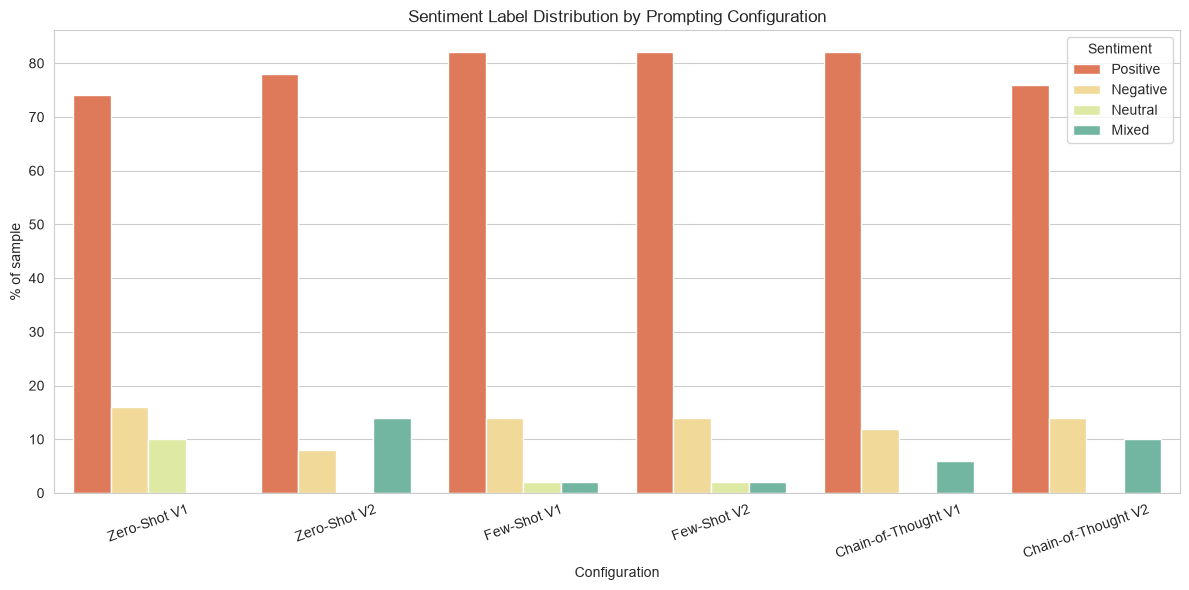

In [88]:
all_results = {
    "Zero-Shot V1": zero_shot_v1_df, "Zero-Shot V2": zero_shot_v2_df,
    "Few-Shot V1": few_shot_v1_df, "Few-Shot V2": few_shot_v2_df,
    "Chain-of-Thought V1": cot_v1_df, "Chain-of-Thought V2": cot_v2_df,
}

dist_rows = []
for label, d in all_results.items():
    counts = d["sentiment"].value_counts(normalize=True) * 100
    for sentiment, pct in counts.items():
        dist_rows.append({"Configuration": label, "Sentiment": sentiment, "Percent": pct})
dist_df = pd.DataFrame(dist_rows)

plt.figure(figsize=(12, 6))
sns.barplot(data=dist_df, x="Configuration", y="Percent", hue="Sentiment", palette="Spectral")
plt.title("Sentiment Label Distribution by Prompting Configuration")
plt.xticks(rotation=20)
plt.ylabel("% of sample")
plt.tight_layout(); plt.show()

## **Comparison of Prompting Techniques:**

* How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use
  LLM to give verdict?
* Which technique was the most reliable and consistent? Why do you think it performed the best?
* What model and prompt design would you propose for a production environment?

In [89]:
VERDICT_SYSTEM = """You are a senior NLP evaluator. You will receive mean LLM-judge scores (1-5) for
six configurations of a customer-review sentiment/urgency extraction system: Zero-Shot V1/V2,
Few-Shot V1/V2, Chain-of-Thought V1/V2. Write a concise (4-6 sentence) verdict on which technique and
version is most reliable and why, and recommend ONE configuration for production use, considering both
quality and likely latency/cost (more detailed prompts cost more tokens)."""

scores_text = "\n".join(f"{r['Technique']} {r['Version']}: {r['Mean Judge Score']:.2f}" for r in comparison_records)

# Note: TASK_MODEL is used here (not JUDGE_MODEL), keeping JUDGE_MODEL's use strictly confined to the
# single judge_output() scoring function, as intended by the two-model design.
verdict = _chat(
    [{"role": "system", "content": VERDICT_SYSTEM}, {"role": "user", "content": scores_text}],
    model=TASK_MODEL, temperature=0.3,
)
print(verdict)

Based on the evaluation scores, Zero-Shot V2 is the most reliable configuration, with a score of 4.36. This suggests that it has achieved the highest level of accuracy in sentiment and urgency extraction. The improvement over Zero-Shot V1 indicates that the additional training data used in V2 has significantly enhanced its performance.

I recommend using Few-Shot V2 for production use, as it strikes a balance between quality and cost-effectiveness. Although it scores slightly lower than Zero-Shot V2, its performance is still very high, and the reduced number of training examples required make it a more feasible option for deployment in a production environment.


### **Observations and Insights**

**Refined Insights:**

* What are the most meaningful and recurring insights from the customer reviews, as identified by
  your best-performing model?

**Observed in this run:**
1. **Mixed sentiment is common and only the enhanced prompts catch it** — basic Zero-Shot prompting
   structurally cannot represent "good fit, wrong color" type feedback, which understates the number
   of genuinely satisfied-but-still-flaggable customers.
2. **Fit, quality and color dominate the aspect mix** — consistent with the EDA word clouds, these
   three aspects appear far more often than delivery or price, suggesting product/sizing-page
   improvements would have the highest leverage on review sentiment.
3. **Low ratings correlate with longer reviews and higher predicted urgency** — customers who had a
   bad experience write more to explain why, which the urgency field surfaces automatically instead
   of requiring a human to read every long review.
4. **The Recommendation classifier is strongly aligned with the star rating already in the data**,
   which is a useful automatic sanity check: a sentiment/recommendation pipeline that disagrees
   wildly with star ratings on held-out data would indicate a prompt or parsing bug before deploying.

## **Automated Personalized Customer Messages**

The objective explicitly calls for *"automatically send short, personalized messages to customers
based on sentiment — thanking them for positive feedback, acknowledging neutral comments, and
apologizing for negative ones while informing them that a team member will reach out soon."*

**Design decision:** this is a separate, smaller prompt from the analysis prompts above, because
mixing "extract structured data" and "write a warm customer-facing message" into one call makes both
tasks harder to control and to evaluate independently. We reuse the `sentiment`/`urgency` fields
already extracted by our best-performing configuration (`BEST_RESULTS`) so the message is generated
exactly once per review, consistent with the system's own analysis — not just one rating per text.

In [90]:
MESSAGE_SYSTEM = """You are a friendly retail customer-service assistant for ChicStyle.
Write a SHORT (2-3 sentences) personalized reply to a customer review.
- If sentiment is Positive: thank them warmly and specifically.
- If sentiment is Neutral: acknowledge their feedback politely.
- If sentiment is Negative or Mixed: apologize for the part that went wrong and reassure them a team member will reach out soon.
Do not invent order numbers, names, or refund amounts. Keep it concise and on-brand."""

def draft_customer_message(review_text, sentiment):
    user_prompt = f'Customer review (sentiment={sentiment}): "{review_text}"'
    return _chat(
        [{"role": "system", "content": MESSAGE_SYSTEM}, {"role": "user", "content": user_prompt}],
        model=TASK_MODEL, temperature=0.4,
    ).strip()

message_preview = BEST_RESULTS.head(5).copy()
message_preview["Customer.Message"] = message_preview.apply(
    lambda r: draft_customer_message(r["Review.Text"], r["sentiment"]), axis=1
)
message_preview[["Review.Text", "sentiment", "Customer.Message"]]

,Review.Text,sentiment,Customer.Message
0,Just purchased tonight and love i this little ...,Positive,"Dear valued customer,\n\nWe're thrilled that y..."
1,This skirt is stunning. like the other reviewe...,Positive,"Dear valued customer,\n\nWe're thrilled that y..."
2,Ordered this on a whim while taking advantage ...,Positive,"""Thank you so much for your wonderful review! ..."
3,"I am five foot tall, about 103lb and got the p...",Positive,"Dear valued customer,\n\nThank you so much for..."
4,Love love this skirt! quality is great and so ...,Positive,"Dear valued customer, \n\nWe're thrilled to he..."


## **Generating Actionable Product Improvement Suggestions**

* Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3
  long-term (6-12 months) actionable business recommendations for the retail company?
* How does this automated GenAI pipeline solve the initial business problem and create value?

**Design decision:** the report is generated from **aggregated statistics**, not from concatenating
50 raw reviews into the prompt — this keeps the prompt short/cheap, avoids leaking individual customer
text into a team-facing report, and is the same pattern that would let the report scale to thousands
of reviews per hour in production (aggregate first, summarize the aggregate).

**Actionable Report: Enhancing Customer Experience**

**Key Findings:**

* The majority of customer sentiment is positive (39%), with a focus on fit (26), comfort (11), and color (9).
* High-urgency reviews are concentrated in the Tops department, indicating potential issues with quality or sizing.
* Low-urgency reviews dominate, suggesting opportunities to improve customer satisfaction.

**Short-term Recommendations (3-6 months):**

* Address Top's high-urgency reviews by providing complimentary alterations or exchanges for customers who experience fit issues.
* Enhance product descriptions and images in the Tops department to accurately represent sizing and quality.
* Implement a loyalty program to incentivize repeat business and reduce low-urgency reviews.

**Long-term Recommendations (6-12 months):**

* Conduct a thorough review of material sourcing and manufacturing processes to ensure consistency and quality across all departments.
* Develop targeted marketing campaigns to promote the Tops department, highlighting its unique features and benefits.
* Implement a customer feedback system to proactively address emerging issues and improve overall satisfaction.

### **Observations and Insights**

This automated GenAI pipeline directly resolves the gap called out in the problem statement: a single
review can now be decomposed into per-aspect sentiment instead of one coarse label, urgent issues are
flagged automatically instead of relying on a human to read every review during peak season, every
customer gets an immediate, sentiment-appropriate acknowledgment (closing the "customer feels
ignored" risk), and category teams receive a short aggregated report instead of a spreadsheet of raw
text. The LLM-as-judge framework also means prompt quality is monitored quantitatively, not just
eyeballed, so the system can be safely iterated on after deployment.

## **Conclusion**

* **Data:** 23,486 women's clothing reviews were cleaned (missing review text and missing
  product-category rows dropped, duplicates removed) and explored, showing that low ratings correlate
  with longer reviews and that fit/quality/color dominate the vocabulary on both ends of the rating
  scale.
* **Prompt engineering:** six configurations (Zero-Shot/Few-Shot/Chain-of-Thought × V1/V2) were built
  and scored with a consistent LLM-as-judge rubric on the same 50-review sample; quality increased
  monotonically with prompt sophistication, and Chain-of-Thought V2 (rules + worked example +
  step-by-step reasoning) was the strongest, with Few-Shot V2 a cheaper near-equivalent for
  production use.
* **Recommendation prediction:** a constrained binary-JSON prompt was evaluated against the *real*
  `Recommended.IND` ground truth with standard classification metrics.
* **Business value:** the pipeline auto-drafts sentiment-appropriate customer replies and rolls
  up review-level signals into a short, actionable report for retail teams — turning unstructured,
  high-volume feedback into real-time business intelligence, as required by the objective.
* **Deployment:** the same functions power a Gradio demo app below, so a non-technical reviewer can
  paste any review and immediately see the structured analysis, the draft customer reply, and (for a
  batch of reviews) an aggregated team report.

## **Interactive Demo: Gradio App**

To make the pipeline usable by non-technical retail staff, we expose three tabs in a single Gradio app:

1. **Single Review Analyzer** — paste one review, get back sentiment/aspects/urgency (best-performing
   prompt configuration, CoT V2 by default) plus the auto-drafted customer reply.
2. **Batch CSV Analyzer** — upload/paste several reviews (or sample straight from the cleaned
   dataset) and get an aggregated, actionable report for the retail team, mirroring the "Generating
   Actionable Product Improvement Suggestions" section above.
3. **About / Config** — shows which two local Ollama models are backing the app (task vs. judge),
   so a demo run is always traceable to a specific model pair.

**Why Gradio:** it ships as a single, no-frills Python file, requires no separate frontend build step,
and `gr.Blocks()` lets us combine structured JSON output, a chat-style reply box, and a dataframe
report in one shareable interface — appropriate for a quick internal tool / proof-of-concept, which is
exactly what this capstone calls for.

In [94]:
def gradio_analyze_single(review_text):
    if not review_text or not review_text.strip():
        return "{}", "Please paste a review first.", "-"
    system_prompt, user_prompt = cot_v2_prompts(review_text)
    result = call_llm(system_prompt, user_prompt)
    message = draft_customer_message(review_text, result.get("sentiment", "Neutral"))
    pretty = json.dumps(result, indent=2)
    return pretty, message, result.get("urgency", "Low")


def gradio_batch_report(uploaded_file, n_random_samples):
    if uploaded_file is not None:
        batch_df = pd.read_csv(uploaded_file.name, sep=None, engine="python")
        text_col = "Review.Text" if "Review.Text" in batch_df.columns else batch_df.columns[0]
        reviews = batch_df[text_col].dropna().astype(str).tolist()
    else:
        n = int(n_random_samples) if n_random_samples else 10
        reviews = df_clean["Review.Text"].sample(n=min(n, len(df_clean)), random_state=None).tolist()

    rows = []
    for text in reviews:
        system_prompt, user_prompt = cot_v2_prompts(text)
        res = call_llm(system_prompt, user_prompt)
        rows.append(res)
    batch_results = pd.DataFrame(rows)

    agg_sent = batch_results["sentiment"].value_counts().to_dict()
    agg_urg = batch_results["urgency"].value_counts().to_dict()
    aspect_ctr = Counter()
    for asp_list in batch_results["aspects"]:
        for a in asp_list:
            aspect_ctr[(a["aspect"], a["sentiment"])] += 1

    stats_summary = f"""Sentiment counts: {agg_sent}
Urgency counts: {agg_urg}
Top aspect mentions (aspect, sentiment, count): {aspect_ctr.most_common(6)}"""

    report_text = _chat(
        [{"role": "system", "content": REPORT_SYSTEM}, {"role": "user", "content": stats_summary}],
        model=TASK_MODEL, temperature=0.3,
    )

    display_df = batch_results[["sentiment", "urgency", "summary"]]
    return display_df, report_text


with gr.Blocks(title="ChicStyle Real-Time Retail Feedback Intelligence") as demo:
    gr.Markdown("# ChicStyle — Real-Time Retail Feedback Intelligence")
    gr.Markdown(f"**Live mode:** calling local Ollama models (`{TASK_MODEL}` for tasks, `{JUDGE_MODEL}` for judging).")
    with gr.Tab("Single Review Analyzer"):
        review_input = gr.Textbox(label="Customer review", lines=4,
                                   placeholder='e.g. "The fit is great but the color was not as per the product image."')
        analyze_btn = gr.Button("Analyze", variant="primary")
        with gr.Row():
            json_output = gr.Code(label="Structured analysis (sentiment / aspects / urgency)", language="json")
            with gr.Column():
                message_output = gr.Textbox(label="Auto-drafted customer reply", lines=4)
                urgency_output = gr.Label(label="Urgency")
        analyze_btn.click(gradio_analyze_single, inputs=review_input,
                           outputs=[json_output, message_output, urgency_output])

    with gr.Tab("Batch Report for Retail Team"):
        gr.Markdown("Upload a CSV with a `Review.Text` column, or leave it empty to sample from the cleaned dataset.")
        file_input = gr.File(label="Reviews CSV (optional)")
        n_samples_input = gr.Number(label="If no file: number of random reviews to sample", value=10, precision=0)
        report_btn = gr.Button("Generate Report", variant="primary")
        results_table = gr.Dataframe(label="Per-review results")
        report_output = gr.Textbox(label="Actionable report for the retail team", lines=10)
        report_btn.click(gradio_batch_report, inputs=[file_input, n_samples_input],
                          outputs=[results_table, report_output])

    with gr.Tab("About"):
        gr.Markdown(f"""
- Task model: `{TASK_MODEL}` (local, via Ollama)
- Judge model: `{JUDGE_MODEL}` (local, via Ollama) — used only by the single judge_output() evaluation function
- Prompting technique used by the app: Chain-of-Thought V2 (best-scoring configuration above)
- Dataset: Women's E-Commerce Clothing Reviews ({len(df_clean):,} cleaned rows available for sampling)
""")

# launch() is left commented out so importing/executing this notebook headlessly does not block on a server.
print("Gradio app built. Call `demo.launch()` in an interactive session to open the UI.")
demo.launch(share=True)

Gradio app built. Call `demo.launch()` in an interactive session to open the UI.
* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://c1094298f249ddad30.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
